In [65]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

# Step 2 Ml processing 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, PolynomialFeatures, StandardScaler, MinMaxScaler  # for l
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# from sklearn.preprocessing import PolynomialFeatures

In [ ]:
# loading data 
data = pd.read_csv('/home/susan/Beta-Bank-project/Data/Beta_bank.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [43]:
# data preprocessing
print()
print(data.info())
print()
print('=' * 40)
print(data.shape)
print()
print('=' * 40)

# Normalize column names: trim spaces, make lowercase, replace spaces with underscores
data.columns = (
    data.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)
print(data.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None

(10000, 14)

Index(['rownumber', 'customerid', 'surname', 'creditscore', 'geography',
 

In [44]:
# checking for missing value 
print(data.isna().sum())
print()
print('=' * 40)
# After missing value, we you do inspection to find out in which row data is missing 
# from 'name'.isna()which missing data
print(data[data['tenure'].isna()].head())
print()
print('=' * 40)
# Checking duplicated columns
print(data.duplicated().sum())


rownumber            0
customerid           0
surname              0
creditscore          0
geography            0
gender               0
age                  0
tenure             909
balance              0
numofproducts        0
hascrcard            0
isactivemember       0
estimatedsalary      0
exited               0
dtype: int64

    rownumber  customerid    surname  creditscore geography  gender  age  \
30         31    15589475    Azikiwe          591     Spain  Female   39   
48         49    15766205        Yin          550   Germany    Male   38   
51         52    15768193  Trevisani          585   Germany    Male   36   
53         54    15702298   Parkhill          655   Germany    Male   41   
60         61    15651280     Hunter          742   Germany    Male   35   

    tenure    balance  numofproducts  hascrcard  isactivemember  \
30     NaN       0.00              3          1               0   
48     NaN  103391.38              1          0               1   
51    

==============================================
###  Task 2 :
 Examine the balance of classes. Train the model without taking into account the imbalance. Briefly describe your findings.


In [59]:
# Create a copy 
df= data.copy()
# Create feature and targets
features = df.drop('exited', axis=1).copy()
target = df['exited'].copy()
# split data
X_train, X_valid, y_train , y_valid = train_test_split(features , target, test_size = 0.25 ,
                                                        stratify=target,
                                                        random_state = 12345)
                                                        # stratify=target means:
                                                        # Keep the same target-class proportions in the training
                                                        #  and validation sets as in the original dataset.Use stratification when:
                                                        # You have a classification problem
                                                        # Your target contains classes, such as 0 and 1
                                                        # The classes are imbalanced
                                                        # You want every dataset to represent the original class distribution

print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
# First, find categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns
print(cat_cols)
# encode the categorical feature using OHE.
categorical_columns = ['geography', 'gender']

X_train_ohe =  pd.get_dummies(X_train[categorical_columns], drop_first= True, dummy_na=True, dtype = int  )
X_valid_ohe = pd.get_dummies(X_valid[categorical_columns], drop_first= True, dummy_na=True, dtype = int  )

# make the validation columns match the training columns:
X_valid_ohe = X_valid_ohe.reindex(
    columns=X_train_ohe.columns,
    fill_value=0
)
# Check results 
print(X_train_ohe.shape)
print(X_valid_ohe.shape)
print(X_train_ohe.columns.equals(X_valid_ohe.columns))

exited
0    5972
1    1528
Name: count, dtype: int64
exited
0    0.796267
1    0.203733
Name: proportion, dtype: float64
Index(['surname', 'geography', 'gender'], dtype='object')
(7500, 5)
(2500, 5)
True


*`Data imbalanced`*: The target classes are imbalanced. Approximately 79.6% of customers stayed, while only 20.4% exited. The majority class is nearly four times larger than the minority class. Therefore, the models may favor class 0 and fail to identify some customers who exit.

In [51]:
# Using Logistic Regression

# rownumber only identifies the row’s position.
# customerid identifies the individual customer.

X_train = X_train.drop(['rownumber', 'customerid', 'surname'], axis=1)
X_valid = X_valid.drop(['rownumber', 'customerid', 'surname'], axis=1)
# Keep all numerical and encoded categorical features

print(numerical_features)
numerical_features = X_train.select_dtypes(include=['int64', 'int32', 'int']).columns
X_train_num = X_train[numerical_features].copy()
X_valid_num = X_valid[numerical_features].copy()
# Apply StandardScaler 
# tandardize only the original numerical features.
standard_scaler = StandardScaler()
standard_scaler.fit(X_train_num)
X_train_standard = standard_scaler.transform(X_train_num)
X_valid_standard = standard_scaler.transform(X_valid_num)
# Convert standardized training data into a DataFrame
X_train_standard = pd.DataFrame(
    X_train_standard,
    columns=numerical_features,
    index=X_train.index
)
# Convert standardized validation data into a DataFrame
X_valid_standard = pd.DataFrame(
    X_valid_standard,
    columns=numerical_features,
    index=X_valid.index
)
X_train_final = pd.concat(
    [X_train_standard, X_train_ohe],
    axis=1
)

X_valid_final = pd.concat(
    [X_valid_standard, X_valid_ohe],
    axis=1)

print(X_train_final.shape)
print(X_valid_final.shape)

print(X_train_final.columns)
print(X_valid_final.columns)

print(X_train_final.columns.equals(X_valid_final.columns))




Index(['rownumber', 'customerid', 'creditscore', 'age', 'numofproducts',
       'hascrcard', 'isactivemember'],
      dtype='object')
(7500, 10)
(2500, 10)
Index(['creditscore', 'age', 'numofproducts', 'hascrcard', 'isactivemember',
       'geography_Germany', 'geography_Spain', 'geography_nan', 'gender_Male',
       'gender_nan'],
      dtype='object')
Index(['creditscore', 'age', 'numofproducts', 'hascrcard', 'isactivemember',
       'geography_Germany', 'geography_Spain', 'geography_nan', 'gender_Male',
       'gender_nan'],
      dtype='object')
True


Precision: 0.6229508196721312
F1 score: 0.32947976878612717


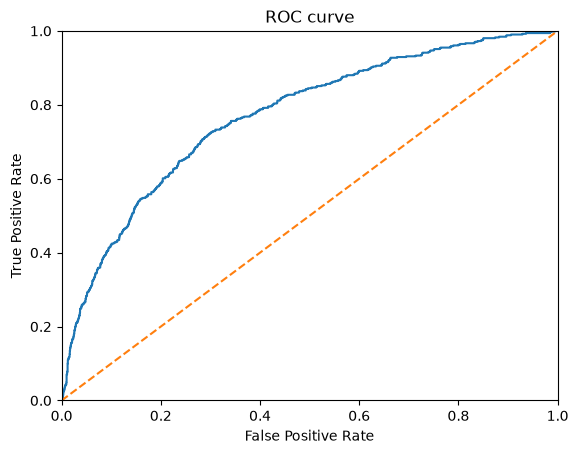

ROC-AUC score: 0.7691443519412997


In [ ]:
# Logistic Regreastion 
model = LogisticRegression(
    random_state=12345,
    max_iter=1000
)

model.fit(X_train_final, y_train)

predicted_valid = model.predict(X_valid_final)
precision = precision_score(y_valid,predicted_valid)
f1 = f1_score(y_valid, predicted_valid)

print("Precision:", precision)
print("F1 score:", f1)

probabilities_valid = model.predict_proba(X_valid_final)
probabilities_one_valid = probabilities_valid[:, 1]
auc_roc = roc_auc_score(y_valid, probabilities_one_valid)
fpr, tpr, thresholds = roc_curve(y_valid,probabilities_one_valid )
plt.figure()

# < plot the graph >
plt.plot(fpr, tpr)
# ROC curve for random model (looks like a straight line)
plt.plot([0, 1], [0, 1], linestyle='--')

# < use the functions set the boundary for the axes from 0 to 1 >
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0,1.0]) 

# < use the functions plt.xlabel() and plt.ylabel() to
#  name the axes "False Positive Rate" and "True Positive Rate" >
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# < add the heading "ROC curve" with the function plt.title() >
plt.title( "ROC curve")
plt.show()
print("ROC-AUC score:", auc_roc)



In [60]:

# RandomForestClassifer 
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    random_state=12345
)

model.fit(X_train_final, y_train)

predicted_valid = model.predict(X_valid_final)

precision = precision_score(y_valid, predicted_valid)
f1 = f1_score(y_valid, predicted_valid)

print("Precision:", precision)
print("F1 score:", f1)

Precision: 0.7533783783783784
F1 score: 0.5540372670807453
